# Khai phá đồ thị IUH - 2026

### Lab 06. Ngày 09/03/2026. Graph lưỡng phân và cặp ghép.

**Yêu cầu 1.** Tìm hiểu về thư viện networkX liên quan đến graph lưỡng phân.

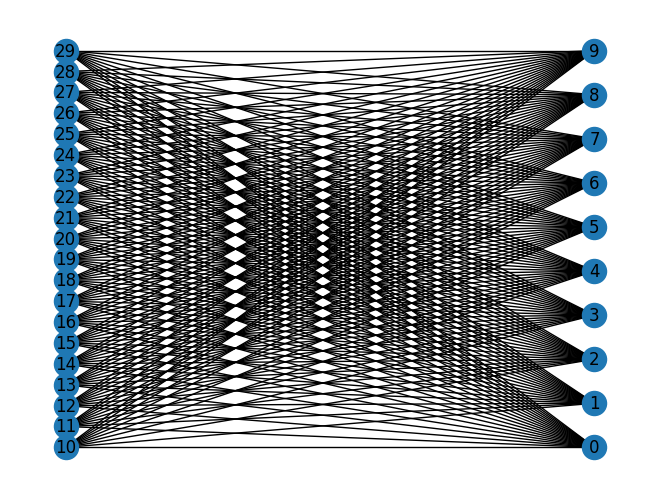

In [1]:
import networkx as nx
from networkx.algorithms import bipartite
G = nx.complete_bipartite_graph(10, 20)
pos = nx.bipartite_layout(G, bipartite.sets(G)[1])
nx.draw(G, pos, with_labels=True)

Tham khảo các thư viện có trong link sau và thực hiện các yêu cầu bên dưới:

https://networkx.org/documentation/stable/reference/algorithms/bipartite.html

1) Cho thông tin về sở thích xem phim của một số người tronng data frame bên dưới. Hãy đếm số lượng người, số lượng phim, vẽ graph lưỡng phân mô tả cho quan hệ này.

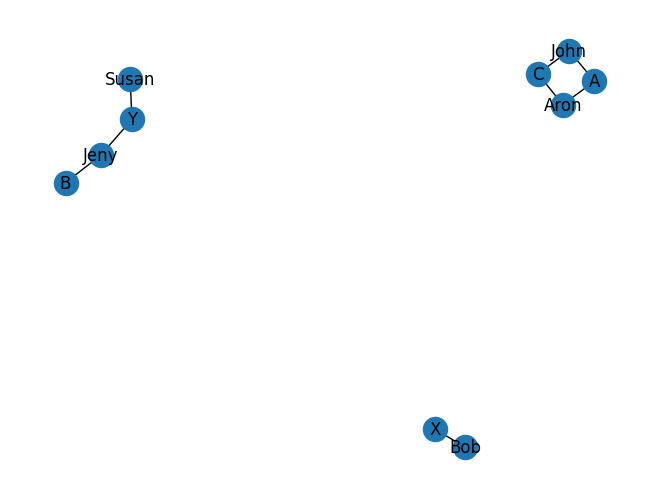

In [2]:
import pandas as pd
df = pd.DataFrame(
    {
        "Name": ["John", "John", "Aron", "Aron", "Jeny", "Jeny", "Susan", "Bob"],
        "Movie": ["A", "C", "C", "A", "Y", "B", "Y", "X"],
    }
)
H = nx.Graph()
H.add_nodes_from(df.Name, bipartite=0)
H.add_nodes_from(df.Movie, bipartite=1)
H.add_edges_from(df.values)
u = [n for n in H.nodes if H.nodes[n]['bipartite'] == 0]
pos = nx.bipartite_layout(H, u)
nx.draw(H, with_labels=True)

In [3]:
df.Name.unique().size, df.Movie.unique().size

(5, 5)

2) Sinh ngẫu nhiên một graph có hai phần $10$, $15$ với hai đỉnh nối nhau theo xác suất $1/5.$ 

a. Tính density của graph vừa sinh ra và degree centrality của graph.

b. Hiển thị ma trận kề của graph này.

c. Liệt kê các bậc của mỗi đỉnh và index của thành phần mà đỉnh đó thuộc về (là 0 hay 1).

d. Tìm cặp ghép cực đại (maximum matching) của graph này. 

In [8]:
import networkx as nx
from networkx.algorithms import bipartite

# sinh graph
K = bipartite.random_graph(15,10, 1/5)
T = bipartite.random_graph(15,10, 1/5)

# lấy 2 tập đỉnh
X = {n for n, d in T.nodes(data=True) if d["bipartite"] == 0}
Y = set(T) - X
# ================= a =================
# density
print("Density:", nx.density(T))

# degree centrality
dc = bipartite.degree_centrality(T, X)
print("Degree centrality:")
for i in dc:
    print(i, ":", dc[i])

# ================= b =================
# ma trận kề
print("\nAdjacency matrix:")
print(nx.adjacency_matrix(T).toarray())

# ================= c =================
# degree + component
deg = dict(T.degree())
comp = list(nx.connected_components(T))

index = {}
for i in range(len(comp)):
    for node in comp[i]:
        index[node] = i

print("\nDegree + Component:")
for node in T.nodes():
    print(node, deg[node], index[node])

# ================= d =================
# maximum matching (FIX LỖI CHỖ NÀY)
matching = bipartite.maximum_matching(T, top_nodes=X)

print("\nMaximum matching:")
for u in matching:
    if u in X:   # tránh in trùng
        print(u, "-", matching[u])

Density: 0.13
Degree centrality:
0 : 0.4
1 : 0.2
2 : 0.30000000000000004
3 : 0.30000000000000004
4 : 0.0
5 : 0.2
6 : 0.30000000000000004
7 : 0.2
8 : 0.30000000000000004
9 : 0.6000000000000001
10 : 0.2
11 : 0.1
12 : 0.30000000000000004
13 : 0.30000000000000004
14 : 0.2
15 : 0.3333333333333333
16 : 0.4666666666666667
17 : 0.3333333333333333
18 : 0.13333333333333333
19 : 0.26666666666666666
20 : 0.2
21 : 0.26666666666666666
22 : 0.2
23 : 0.13333333333333333
24 : 0.26666666666666666

Adjacency matrix:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 0 

3) Có một nhóm $7$ vận động viên muốn tham gia thi chạy trên $7$ trong số $10$ đường đua. Cho biết ma trận trọng số của mỗi vận động viên khi chạy trên từng con đường ($c_{ij}$ cho biết thời gian vận động viên $i$ chạy trên con đường $j$), đây là các con số nguyên từ $11 \to 20.$ Yêu cầu đặt ra là cần ghép cặp $7$ người với $7$ đường đua để tổng thời gian chạy là ít nhất. Hãy xây dựng mô hình graph thích hợp và giải bài toán này.

In [9]:
#CODE HERE
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite

# ================= 1. Sinh dữ liệu =================
np.random.seed(0)

# ma trận chi phí 7x10 (11 → 20)
cost = np.random.randint(11, 21, (7, 10))
print("Cost matrix:\n", cost)

# ================= 2. Tạo graph =================
G = nx.Graph()

# node
workers = list(range(7))
jobs = list(range(7, 17))   # 10 đường đua

G.add_nodes_from(workers, bipartite=0)
G.add_nodes_from(jobs, bipartite=1)

# thêm cạnh + trọng số
for i in range(7):
    for j in range(10):
        G.add_edge(i, j+7, weight=cost[i][j])

# ================= 3. Matching tối ưu =================
matching = bipartite.minimum_weight_full_matching(G, top_nodes=workers)

# ================= 4. In kết quả =================
total_cost = 0

print("\nMatching tối ưu:")
for u in matching:
    if u in workers:
        v = matching[u]
        w = G[u][v]['weight']
        total_cost += w
        print(f"VĐV {u} -> Đường {v-7} | time = {w}")

print("\nTotal time =", total_cost)

Cost matrix:
 [[16 11 14 14 18 20 14 16 13 15]
 [18 17 19 19 12 17 18 18 19 12]
 [16 20 19 20 15 14 11 14 16 11]
 [13 14 19 12 14 14 14 18 11 12]
 [20 20 11 15 18 14 13 18 13 11]
 [11 15 16 16 17 19 15 12 15 20]
 [19 12 12 18 20 20 14 17 18 13]]

Matching tối ưu:
VĐV 0 -> Đường 1 | time = 11
VĐV 1 -> Đường 4 | time = 12
VĐV 2 -> Đường 6 | time = 11
VĐV 3 -> Đường 8 | time = 11
VĐV 4 -> Đường 9 | time = 11
VĐV 5 -> Đường 0 | time = 11
VĐV 6 -> Đường 2 | time = 12

Total time = 79


**Yêu cầu 2.** Xử lý nâng cao.

4) Cho bảng dữ liệu ở file **data.xlsx** mô tả việc lưu trữ $18$ file trong danh sách $\{A,B,C,...,Q\}$ vào $10$ server $\{1,2,...,10\}$, trong đó file $i$ được lưu vào server $j$ nếu ở ô $(i,j)$ của bảng có đánh dấu $\times$. Hãy thực hiện các yêu cầu sau: 

a. Dùng thư viện Pandas để đọc dữ liệu này và lưu vào dataframe như code mẫu bên dưới, sau đó chuyển dữ liệu này sang dạng graph lưỡng phân và trực quan thích hợp, tham khảo thêm link sau đây: https://stackoverflow.com/questions/61112420/pandas-to-bipartite-graph

b. Một graph lưỡng phân được gọi là *regular (graph đều)* nếu một trong hai bên trái \& phải của nó có tất cả các đỉnh đều đồng bậc (VD: nếu tất cả các đỉnh của phe bên trái đều cùng có bậc $3$ hoặc tất cả các đỉnh của phe bên phải đều cùng có bậc $7$ thì các graph như vậy sẽ regular). Hãy viết code kiểm tra xem graph $G$ ở trên có regular không?

c. Người ta muốn lấy ra tất cả $18$ file từ các server đã cho sao cho mỗi server được dùng không quá $2$ lần. Hãy tìm cách điều chỉnh hàm *maximum_matching* của thư viện networkx để kiểm tra xem có thể thực hiện được điều này hay không?

                1    2    3    4    5    6    7    8    9    10
File \ Server                                                  
A              NaN  NaN  NaN  NaN    x  NaN    x  NaN  NaN  NaN
B              NaN    x  NaN    x    x  NaN  NaN  NaN  NaN    x
C              NaN  NaN    x  NaN  NaN    x  NaN  NaN  NaN  NaN
D              NaN  NaN  NaN  NaN  NaN  NaN  NaN    x    x  NaN
E                x  NaN  NaN    x  NaN  NaN    x  NaN  NaN  NaN
F              NaN    x  NaN  NaN  NaN  NaN  NaN  NaN  NaN    x
G              NaN  NaN    x  NaN  NaN    x  NaN  NaN  NaN  NaN
H              NaN  NaN    x  NaN    x  NaN  NaN  NaN  NaN  NaN
I              NaN    x  NaN  NaN  NaN  NaN  NaN    x    x  NaN
J              NaN  NaN  NaN    x  NaN  NaN  NaN  NaN  NaN    x
K              NaN  NaN  NaN  NaN  NaN  NaN    x  NaN  NaN    x
L                x  NaN  NaN  NaN  NaN    x  NaN  NaN  NaN  NaN
M              NaN  NaN    x  NaN  NaN  NaN  NaN  NaN    x  NaN
N                x  NaN  NaN  NaN  NaN  

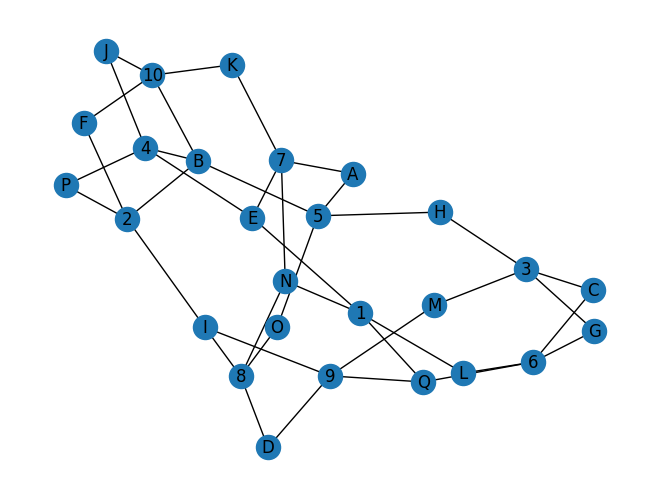

In [10]:
#CODE HERE
#a
import pandas as pd
import networkx as nx

# đọc file
df = pd.read_excel("data.xlsx", index_col=0)
print(df)

# tạo graph
G = nx.Graph()

# nodes
files = list(df.index)        # A → Q (18 file)
servers = list(df.columns)    # 1 → 10

G.add_nodes_from(files, bipartite=0)
G.add_nodes_from(servers, bipartite=1)

# thêm cạnh
for i in files:
    for j in servers:
        if str(df.loc[i, j]).lower() == 'x':
            G.add_edge(i, j)

print("Number of edges:", G.number_of_edges())
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.show()

In [11]:
# degree
deg = dict(G.degree())

# tách 2 phía
files = [n for n, d in G.nodes(data=True) if d['bipartite'] == 0]
servers = list(set(G) - set(files))

# degree từng phía
deg_files = [deg[n] for n in files]
deg_servers = [deg[n] for n in servers]

# check
is_regular_files = len(set(deg_files)) == 1
is_regular_servers = len(set(deg_servers)) == 1

print("Regular phía file:", is_regular_files)
print("Regular phía server:", is_regular_servers)

if is_regular_files or is_regular_servers:
    print("=> Graph là regular")
else:
    print("=> Graph KHÔNG regular")

Regular phía file: False
Regular phía server: True
=> Graph là regular


In [12]:
#c
from networkx.algorithms import bipartite

H = nx.Graph()

# files giữ nguyên
files = [n for n, d in G.nodes(data=True) if d['bipartite'] == 0]
servers = list(set(G) - set(files))

# thêm file
H.add_nodes_from(files, bipartite=0)

# nhân đôi server
server_copy = []
for s in servers:
    s1 = str(s) + "_1"
    s2 = str(s) + "_2"
    server_copy.extend([s1, s2])
    H.add_node(s1, bipartite=1)
    H.add_node(s2, bipartite=1)

# thêm cạnh
for u, v in G.edges():
    if u in files:
        H.add_edge(u, str(v) + "_1")
        H.add_edge(u, str(v) + "_2")
    else:
        H.add_edge(v, str(u) + "_1")
        H.add_edge(v, str(u) + "_2")

# matching
matching = bipartite.maximum_matching(H, top_nodes=files)

# kiểm tra đủ 18 file không
matched_files = [u for u in matching if u in files]

print("Số file ghép được:", len(matched_files))

if len(matched_files) == len(files):
    print("=> THỎA mãn (mỗi server ≤ 2 lần)")
else:
    print("=> KHÔNG thỏa")

Số file ghép được: 17
=> THỎA mãn (mỗi server ≤ 2 lần)
